# **Training Data In machine Learning**

## **Introduction:**

In this assignment, we will explore key aspects of training data management in machine learning, including sampling techniques, class imbalance, data labeling, and model performance evaluation.

## **1. Import and Explore the Wine dataset**

In [24]:
# Import and load the dataset

from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

wine = load_wine()

In [2]:
# Convert to a DataFrame

wine_data = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target/class column
wine_data["target"] = wine.target

wine_data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
# Check the class distribution

wine_data["target"].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

## **2. Apply Sampling Techniques**

#### **2.1 Simple random sampling**

In [3]:
# Sampling 50 observations using Simple Random Sampling

wine_random_sample = wine_data.sample(n=50, random_state=42)

wine_random_sample.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080.0,0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.60,0.77,2.31,600.0,2
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1


In [6]:
# Check the class distribution

wine_random_sample["target"].value_counts().sort_index()

target
0    17
1    20
2    13
Name: count, dtype: int64

#### **2.2 Stratified sampling**

In [ ]:
# Stratified sample of 50 observations

stratified_sample, _ = train_test_split(
    wine_data,
    train_size=50,
    stratify=wine_data["target"],
    random_state=42)

# Check the class distribution

stratified_sample["target"].value_counts().sort_index()

target
0    17
1    20
2    13
Name: count, dtype: int64

#### **2.3 Visualize the class distribution** 

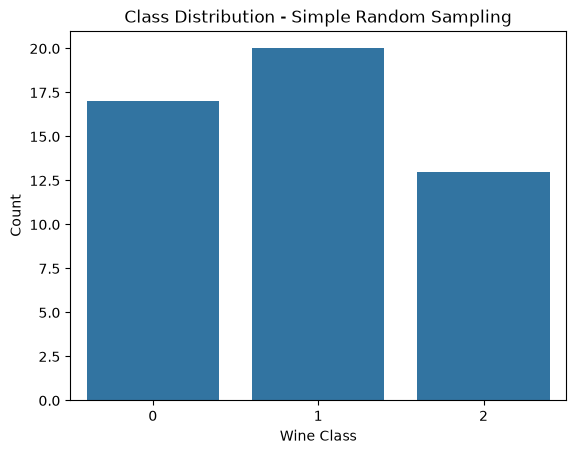

In [ ]:
# Visualize the class distribution_Simple random sampling


sns.countplot(data=wine_random_sample, x="target")

plt.title("Class Distribution - Simple Random Sampling")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()


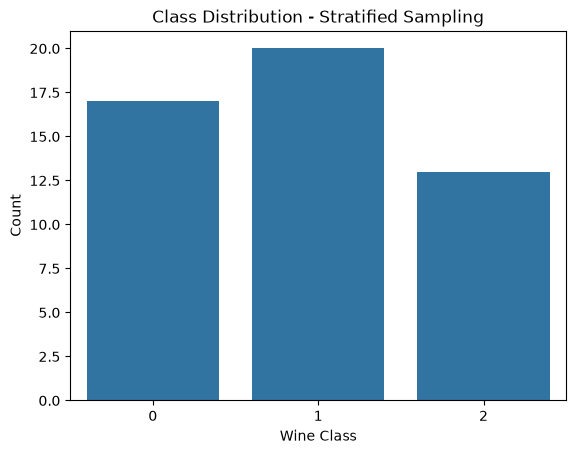

In [ ]:
# Visualize the class_Stratified sampling

sns.countplot(data=stratified_sample, x="target")

plt.title("Class Distribution - Stratified Sampling")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

## **3.Handle Class Imbalance**

### **3.1 Create an imbalanced dataset**

In [ ]:
# Separate the classes

class_0 = wine_data[wine_data["target"] == 0]
class_1 = wine_data[wine_data["target"] == 1]
class_2 = wine_data[wine_data["target"] == 2]

# Reduce Class 2 to only 10 observations

class_2_reduced = class_2.sample(n=10, random_state=42)

# Combine the classes

imbalanced_data = pd.concat([class_0, class_1, class_2_reduced])

# Check distribution

imbalanced_data["target"].value_counts()

target
1    71
0    59
2    10
Name: count, dtype: int64

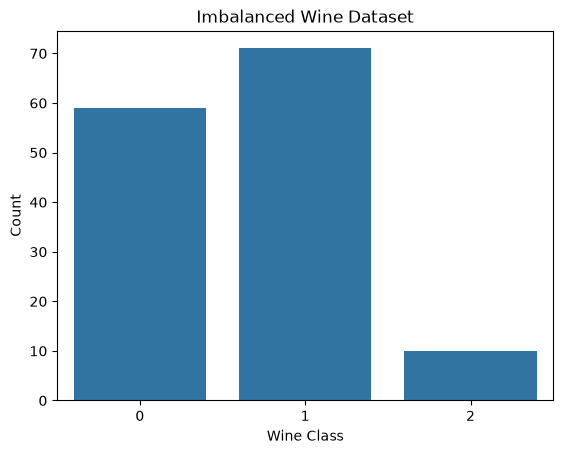

In [ ]:
# Visualize class imbalance

sns.countplot(data=imbalanced_data, x="target")
plt.title("Imbalanced Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()


#### **3.2 Apply SMOTE**

In [17]:
# Separate features and target

X = imbalanced_data.drop("target", axis=1)
y = imbalanced_data["target"]

In [19]:
# Split the data before applying SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42)

In [21]:
# Apply SMOTE

import sys
!{sys.executable} -m pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
target
1    50
0    41
2     7
Name: count, dtype: int64

After SMOTE:
target
0    50
1    50
2    50
Name: count, dtype: int64


#### **3.3 Train Random Forest on the imbalanced data** 

In [26]:
# Train the Random Forest Classifier

rf_imbalanced = RandomForestClassifier(random_state=42)

rf_imbalanced.fit(X_train, y_train)

y_pred_imbalanced = rf_imbalanced.predict(X_test)

print("Random Forest for Imbalanced Data")
print(classification_report(y_test, y_pred_imbalanced))

Random Forest for Imbalanced Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00         3

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



#### **3.4 Train Random Forest on the SMOTE-balanced data**

In [27]:
# Train the Random Forest Classifier 

rf_balanced = RandomForestClassifier(random_state=42)

rf_balanced.fit(X_train_balanced, y_train_balanced)

y_pred_balanced = rf_balanced.predict(X_test)

print("Random Forest - SMOTE Balanced Data")
print(classification_report(y_test, y_pred_balanced))

Random Forest - SMOTE Balanced Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00         3

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



##### **Insights**
Both the Random Forest model trained on the imbalanced data and the model trained on the SMOTE-balanced data achieved precision, recall, and F1-scores of 1.00 on the test set. Therefore, SMOTE did not produce an observable improvement in this experiment. However, the minority class contained only three observations in the test set. A larger test set or cross-validation would provide a more reliable comparison.